Mounted at /content/drive


/tmp/ipython-input-4081521545.py:27: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extraction des features pour le train...
Extraction des features pour le test...
LabelEncoder enregistré !

Classification report :
              precision    recall  f1-score   support

        Acne       0.87      0.94      0.90        65
      Eczema       0.95      0.87      0.91       114
       Moles       0.80      0.90      0.85        40

    accuracy                           0.89       219
   macro avg       0.87      0.90      0.89       219
weighted avg       0.90      0.89      0.90       219

Précision totale (accuracy) : 0.89


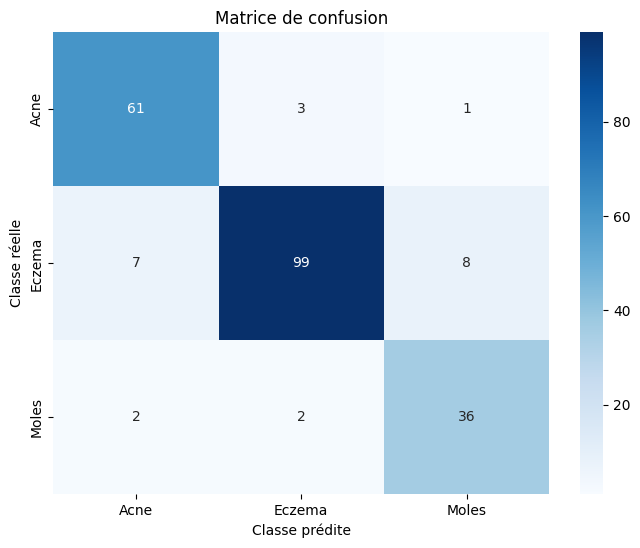

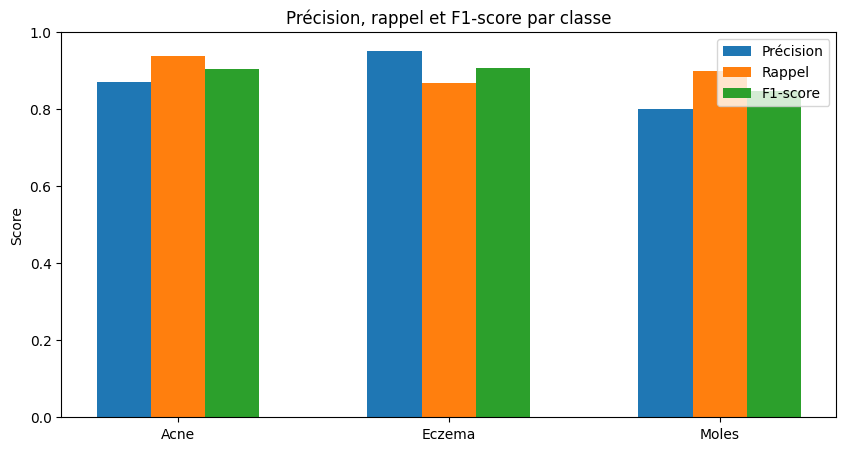

Acne -> Précision: 0.87, Rappel: 0.94, F1-score: 0.90
Eczema -> Précision: 0.95, Rappel: 0.87, F1-score: 0.91
Moles -> Précision: 0.80, Rappel: 0.90, F1-score: 0.85
SVM enregistré !
MobileNetV2 enregistré !


In [1]:
# ===============================
# 1️⃣ Monter Google Drive
# ===============================
from google.colab import drive
drive.mount('/content/drive')

# ===============================
# 2️⃣ Importer les librairies
# ===============================
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import joblib
import tensorflow as tf
import pickle

# ===============================
# 3️⃣ Charger MobileNetV2 sans la couche finale
# ===============================
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

# ===============================
# 4️⃣ Fonction pour charger les images et extraire les features
# ===============================
def load_images_and_extract_features(folder_path):
    features = []
    labels = []
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_folder):
            continue
        for img_name in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_name)
            try:
                img = image.load_img(img_path, target_size=(224, 224))
                x = image.img_to_array(img)
                x = np.expand_dims(x, axis=0)
                x = preprocess_input(x)
                feature = base_model.predict(x, verbose=0)
                features.append(feature.flatten())
                labels.append(class_name)
            except:
                print(f"Erreur avec l'image {img_path}, ignorée.")
    return np.array(features), np.array(labels)

# ===============================
# 5️⃣ Définir les chemins Train et Test
# ===============================
train_path = '/content/drive/MyDrive/datasetD/Train'
test_path = '/content/drive/MyDrive/datasetD/Test'

# ===============================
# 6️⃣ Extraire les features
# ===============================
print("Extraction des features pour le train...")
X_train, y_train = load_images_and_extract_features(train_path)
print("Extraction des features pour le test...")
X_test, y_test = load_images_and_extract_features(test_path)

# ===============================
# 7️⃣ Encoder les labels
# ===============================
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Enregistrer le LabelEncoder pour l'utiliser plus tard
with open('/content/drive/MyDrive/datasetD/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("LabelEncoder enregistré !")

# ===============================
# 8️⃣ Entraîner le SVM avec gestion du déséquilibre
# ===============================
svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
svm.fit(X_train, y_train_enc)

# ===============================
# 9️⃣ Prédire et évaluer
# ===============================
y_pred = svm.predict(X_test)
print("\nClassification report :")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# Précision totale
accuracy = accuracy_score(y_test_enc, y_pred)
print(f"Précision totale (accuracy) : {accuracy:.2f}")

# ===============================
# 🔹 Matrice de confusion
# ===============================
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.title('Matrice de confusion')
plt.show()

# ===============================
# 🔹 Graphique précision, rappel et F1-score par classe
# ===============================
precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, y_pred)

plt.figure(figsize=(10,5))
x = np.arange(len(le.classes_))
width = 0.2

plt.bar(x - width, precision, width, label='Précision')
plt.bar(x, recall, width, label='Rappel')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, le.classes_)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Précision, rappel et F1-score par classe')
plt.legend()
plt.show()

# Afficher les scores par classe
for i, cls in enumerate(le.classes_):
    print(f"{cls} -> Précision: {precision[i]:.2f}, Rappel: {recall[i]:.2f}, F1-score: {f1[i]:.2f}")

# ===============================
# 🔹 Sauvegarder les modèles
# ===============================
joblib.dump(svm, '/content/drive/MyDrive/datasetD/svm_skin_model.pkl')
print("SVM enregistré !")

base_model.save('/content/drive/MyDrive/datasetD/mobilenetv2_features_model.keras')
print("MobileNetV2 enregistré !")


In [2]:
import pickle

# Enregistrer le LabelEncoder
with open('/content/drive/MyDrive/datasetD/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("LabelEncoder enregistré !")


LabelEncoder enregistré !


Saving aa.jpeg to aa.jpeg
Image uploadée : aa.jpeg


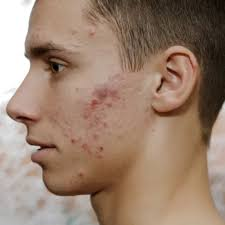

Classe prédite : Acne
Maladie détectée : Acne

💊 Nom complet : Acné 

📝 Description :
 L'acné se manifeste par des lésions inflammatoires (papules rouges, pustules avec point blanc) et non-inflammatoires (comédons ouverts ou fermés). Les caractéristiques observables incluent :

• Aspect visuel : Zones rouges inflammatoires, possibles têtes blanches (pus), points noirs
• Texture : Surface irrégulière, relief cutané perturbé
• Distribution : Typiquement sur visage (front, nez, joues, menton), dos, poitrine
• Sévérité variable : De légère (quelques comédons) à sévère (nodules, kystes)

✅ Recommandations :
 Prise en charge recommandée :
✓ Nettoyage doux 2x/jour (produits non comédogènes)
✓ Éviter de manipuler les lésions
✓ Traitements topiques : peroxyde de benzoyle, rétinoïdes
✓ Consultation dermatologique si acné modérée à sévère
✓ Possibles traitements : antibiotiques, isotrétinoïne (cas sévères)

⚠️ Urgence : Si les symptômes persistent ou s’aggravent, consultez un dermatologue.


In [3]:
# ✅ Importer les librairies
import joblib
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
from google.colab import files
from IPython.display import Image, display
import pickle

# 1️⃣ Charger les modèles et le LabelEncoder
svm = joblib.load('/content/drive/MyDrive/datasetD/svm_skin_model.pkl')
base_model = load_model('/content/drive/MyDrive/datasetD/mobilenetv2_features_model.keras')
le = pickle.load(open('/content/drive/MyDrive/datasetD/label_encoder.pkl', 'rb'))

# 2️⃣ Upload et prédiction d'une image
uploaded = files.upload()
for filename in uploaded.keys():
    print("Image uploadée :", filename)
    display(Image(filename))

    # Préparer l'image
    img = image.load_img(filename, target_size=(224,224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # Extraire les features
    feature = base_model.predict(x, verbose=0).flatten().reshape(1, -1)

    # Prédire avec le SVM
    pred_index = svm.predict(feature)[0]
    pred_class = le.inverse_transform([pred_index])[0]

    print("Classe prédite :", pred_class)
# ✅ Table d'urgence et recommandations
MEDICAL_INFO = {
    'acne': {
        'nom_complet': 'Acné ',
        'description': """L'acné se manifeste par des lésions inflammatoires (papules rouges, pustules avec point blanc) et non-inflammatoires (comédons ouverts ou fermés). Les caractéristiques observables incluent :

• Aspect visuel : Zones rouges inflammatoires, possibles têtes blanches (pus), points noirs
• Texture : Surface irrégulière, relief cutané perturbé
• Distribution : Typiquement sur visage (front, nez, joues, menton), dos, poitrine
• Sévérité variable : De légère (quelques comédons) à sévère (nodules, kystes)""",

        'causes': """Causes principales :
• Hyperséborrhée (production excessive de sébum)
• Obstruction des follicules pileux
• Prolifération bactérienne (Cutibacterium acnes)
• Inflammation locale
• Facteurs : hormones, stress, alimentation, cosmétiques comédogènes""",

        'recommandations': """Prise en charge recommandée :
✓ Nettoyage doux 2x/jour (produits non comédogènes)
✓ Éviter de manipuler les lésions
✓ Traitements topiques : peroxyde de benzoyle, rétinoïdes
✓ Consultation dermatologique si acné modérée à sévère
✓ Possibles traitements : antibiotiques, isotrétinoïne (cas sévères)""",

        'urgence': 'NON URGENT',
        'couleur': '#ef4444'
    },

    'eczema': {
        'nom_complet': 'Dermatite atopique / Eczéma',
        'description': """L'eczéma présente des lésions inflammatoires chroniques avec prurit intense. Aspects caractéristiques :

• Aspect visuel : Plaques rouges, érythémateuses, mal délimitées
• Texture : Peau sèche, squameuse, desquamation fine
• Phases : Aiguë (suintement, vésicules) → Chronique (épaississement, lichénification)
• Distribution : Plis (coudes, genoux), mains, cou, visage chez l'enfant""",

        'causes': """Physiopathologie :
• Barrière cutanée altérée (déficit en filaggrine)
• Réaction immunitaire type Th2
• Terrain atopique (prédisposition génétique)
• Facteurs déclenchants : allergènes, irritants, stress, climat sec""",

        'recommandations': """Prise en charge recommandée :
✓ Hydratation intensive quotidienne (émollients)
✓ Éviction des facteurs déclenchants
✓ Dermocorticoïdes pendant les poussées
✓ Antihistaminiques si prurit sévère
✓ Suivi dermatologique régulier
✓ Éducation thérapeutique du patient""",

        'urgence': 'NON URGENT (sauf surinfection)',
        'couleur': '#eab308'
    },

    'moles': {
        'nom_complet': 'Naevus mélanocytaire (Grain de beauté)',
        'description': """Les grains de beauté sont des lésions mélanocytaires bénignes dans la majorité des cas. Caractéristiques normales :

• Aspect visuel : Macule ou papule pigmentée, couleur brune uniforme
• Forme : Symétrique, bords réguliers et nets
• Diamètre : Généralement < 6mm
• Stabilité : Absence d'évolution récente
• Types : Plans, surélevés, parfois poilus""",

        'causes': """Origine et facteurs :
• Prolifération bénigne de mélanocytes
• Facteurs génétiques (type de peau, antécédents familiaux)
• Exposition solaire (favorise l'apparition)
• Apparition : Enfance/adolescence, stabilisation à l'âge adulte""",

        'recommandations': """Surveillance recommandée (Règle ABCDE) :
✓ A - Asymétrie : forme asymétrique → suspect
✓ B - Bords : irréguliers, déchiquetés → suspect
✓ C - Couleur : hétérogène, plusieurs teintes → suspect
✓ D - Diamètre : > 6mm → surveillance rapprochée
✓ E - Évolution : changement récent → CONSULTATION URGENTE
✓ Protection solaire rigoureuse (SPF 50+)
✓ Auto-surveillance mensuelle
✓ Consultation annuelle chez le dermatologue""",

        'urgence': 'Surveillance régulière nécessaire',
        'couleur': '#3b82f6'
    },

    'skincancer': {
        'nom_complet': 'Suspicion de cancer cutané',
        'description': """⚠️ Signes évocateurs de lésion maligne nécessitant une évaluation urgente :

• Aspect visuel : Lésion asymétrique, coloration hétérogène (brun, noir, rouge, blanc)
• Bords : Irréguliers, encochés, mal délimités
• Diamètre : Souvent > 6mm (mais pas toujours)
• Évolution : Modification récente (taille, couleur, forme, épaisseur)
• Surface : Possiblement ulcérée, croûteuse, saignant au moindre contact""",

        'causes': """Facteurs de risque majeurs :
• Exposition solaire cumulative (UV)
• Antécédents de coups de soleil sévères
• Phototype clair (peau, cheveux, yeux clairs)
• Antécédents personnels/familiaux de mélanome
• Nombre élevé de naevus (> 50)
• Immunosuppression
• Exposition aux UV artificiels (cabines de bronzage)""",

        'recommandations': """⚠️ CONSULTATION DERMATOLOGIQUE URGENTE NÉCESSAIRE

Actions immédiates :
✓ Prendre RDV en urgence avec un dermatologue
✓ Biopsie diagnostique indispensable
✓ Ne PAS manipuler la lésion
✓ Photographier pour suivre l'évolution
✓ Exérèse chirurgicale si confirmé

Pronostic : Excellent si détection précoce
Le mélanome détecté tôt a un taux de guérison > 95%""",

        'urgence': '🚨 URGENT - CONSULTATION RAPIDE OBLIGATOIRE',
        'couleur': '#dc2626'
    }
}
# Récupérer urgence et recommandation
# ✅ Récupérer informations médicales après la prédiction
# Récupérer informations médicales après la prédiction
result = MEDICAL_INFO.get(pred_class.lower(), None)  # .lower() pour correspondre aux clés

if result:
    print("Maladie détectée :", pred_class)
    print("\n💊 Nom complet :", result["nom_complet"])
    print("\n📝 Description :\n", result["description"])
    print("\n✅ Recommandations :\n", result["recommandations"])

    # Adapter le message d'urgence pour certaines maladies
    if pred_class.lower() in ['acne', 'eczema', 'moles']:
        print("\n⚠️ Urgence : Si les symptômes persistent ou s’aggravent, consultez un dermatologue.")
    else:
        print("\n⚠️ Urgence :", result["urgence"])
else:
    print("Maladie détectée :", pred_class)
    print("❌ Pas d’information médicale disponible pour cette classe")


